In [70]:
import controlsim as csm
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

Plant Definition

In [71]:
A = -1
B = 0.5
C = 1
D = 0
sys = ctrl.ss(A, B, C, D)
G = ctrl.ss2tf(sys)
dt = 0.01
plant = csm.ProcessDefinition(G, 0.0, dt=dt)

Reference Model Definition: The model we want the plant to follow

In [72]:
Am = -1
Bm = 1
Cm = 1
Dm = 0
sysm = ctrl.ss(Am, Bm, Cm, Dm)
plant_ref = csm.ProcessDefinition(sysm, 0.0, dt=dt)

Output Comparison: Plant vs Reference Model

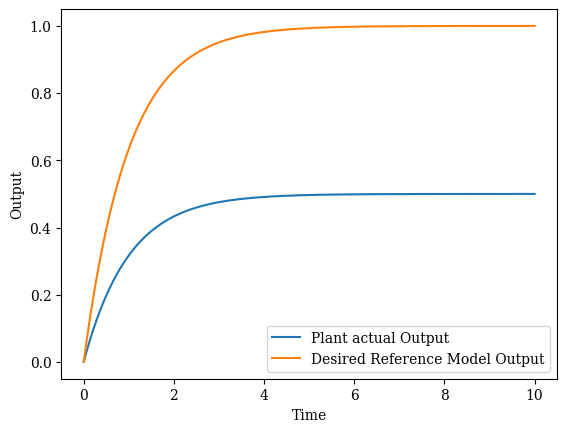

In [73]:
t = np.arange(0, 10, dt)
R = np.ones_like(t)

for r in R:
    plant.step(r)
    plant_ref.step(r)

plt.figure()
plt.plot(plant.t, plant.y, label="Plant actual Output")
plt.plot(plant_ref.t, plant_ref.y, label="Desired Reference Model Output")
plt.xlabel("Time")
plt.ylabel("Output")
plt.legend()
plt.show()

Ideal K_x and K_r for perfect tracking

In [74]:
K_x = (Am - A) / B
K_r = (Bm) / B
print(f"Ideal K_x: {K_x:.2f}, Ideal K_r: {K_r:.2f}")

Ideal K_x: 0.00, Ideal K_r: 2.00


-The MRAC Design Loop with Adaptive Law Updates

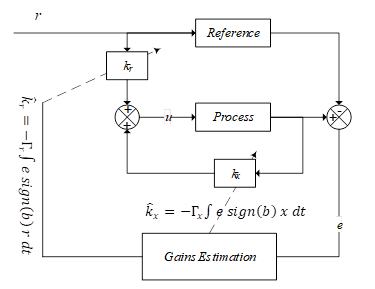

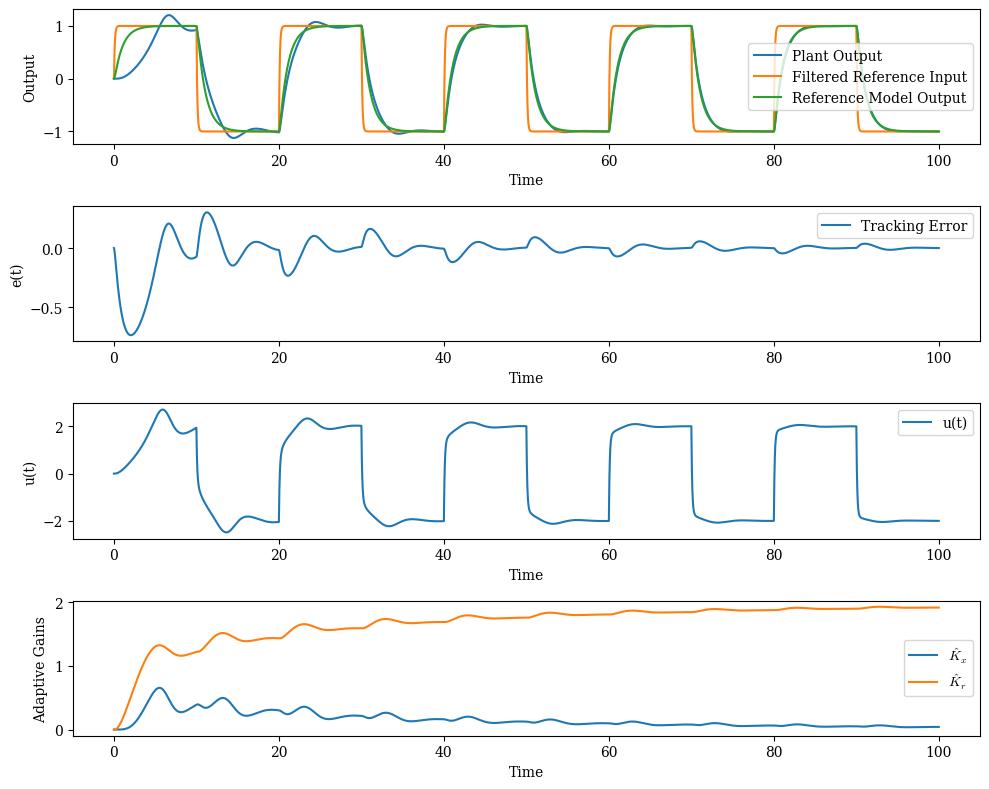

In [75]:
t = np.arange(0, 100, dt)
R = np.ones_like(t)
x = 0
x_m = 0
K_xhat = 0
K_rhat = 0
e_h = []
G_f = ctrl.tf([1], [0.1, 1])
spf = csm.ProcessDefinition(G_f, 0.0, dt=dt)  # setpoint filter for reference input
spf.reset()
plant.reset()
plant_ref.reset()
Gamma = 1

K_x_h = np.array([])
K_r_h = np.array([])
u_h = np.array([])

R = np.sign(np.sin(2 * np.pi * 0.05 * t))  # Square wave reference input

for r in R:
    _, ref, t = spf.step(r)
    u = K_xhat * x + K_rhat * ref
    x, y, t = plant.step(u)
    x_m, y_m, t_m = plant_ref.step(ref)
    e = y - y_m

    # Adaptive law updates
    K_xhat_dot = -Gamma * e * B * x
    K_rhat_dot = -Gamma * e * B * ref

    K_xhat += K_xhat_dot * dt
    K_rhat += K_rhat_dot * dt
    # save the results
    e_h.append(e)
    K_x_h = np.append(K_x_h, K_xhat)
    K_r_h = np.append(K_r_h, K_rhat)
    u_h = np.append(u_h, u)

fig, axes = plt.subplots(4, 1, figsize=(10, 8))

axes[0].plot(plant.t, plant.y, label="Plant Output")
axes[0].plot(spf.t, spf.y, label="Filtered Reference Input")
axes[0].plot(plant_ref.t, plant_ref.y, label="Reference Model Output")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Output")
axes[0].legend()

axes[1].plot(plant.t[0 : len(e_h)], e_h, label="Tracking Error")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("e(t)")
axes[1].legend()

axes[2].plot(plant.t[0 : len(u_h)], u_h, label="u(t)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("u(t)")
axes[2].legend()

axes[3].plot(plant.t[0 : len(K_x_h)], K_x_h, label=r"$\hat{K}_x$")
axes[3].plot(plant.t[0 : len(K_r_h)], K_r_h, label=r"$\hat{K}_r$")
axes[3].set_xlabel("Time")
axes[3].set_ylabel("Adaptive Gains")
axes[3].legend()

plt.tight_layout()
plt.show()